# 🚀 Predictive Maintenance: Remaining Useful Life (RUL) Prediction
### NASA C-MAPSS Turbofan Engine Degradation Dataset (FD001)

**Author:** Chaitanya Naga Pramila R
**GitHub:** [Pramila6578](https://github.com/Pramila6578)
**LinkedIn:** [Profile](https://www.linkedin.com/in/pramila-r)

---


## 1. Project Overview

Predictive Maintenance is one of the most impactful applications of Machine Learning in modern industry. Instead of waiting for equipment to fail — or over-maintaining it on a fixed schedule — organizations use sensor data to monitor asset health and predict failures before they happen. This reduces unplanned downtime, optimizes maintenance scheduling, and lowers operating costs.

In this project, NASA's **Commercial Modular Aero-Propulsion System Simulation (C-MAPSS)** dataset is used to build a Machine Learning model that predicts the **Remaining Useful Life (RUL)** of turbofan jet engines from historical sensor measurements.

**Why this project matters (industrial context):** the same approach used here — tracking sensor drift over operating cycles to predict time-to-failure — applies directly to rotating machinery, motors, and production-line equipment in manufacturing plants. This project bridges hands-on industrial automation experience (PLC/SCADA sensor data) with a full applied Machine Learning workflow.


## 2. Problem Statement

Aircraft engines degrade gradually during operation due to wear and tear. Predicting the *exact* moment of failure is difficult, but it is possible to estimate **how many operating cycles remain** before an engine reaches failure.

**Objective:** Build a regression model that estimates the Remaining Useful Life (RUL) of an engine based on its operating conditions and sensor measurements.


## 3. Dataset Information

**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation — subset **FD001**

| Property | Value |
|---|---|
| Training engines | 100 |
| Testing engines | 100 |
| Operating conditions | 1 |
| Fault modes | 1 |
| Sensor measurements | 21 |
| Operational settings | 3 |

Each row in the dataset represents **one operating cycle** of one engine. The training set contains complete run-to-failure histories, which is what makes it possible to calculate RUL directly.


## 4. Project Workflow

1. Import Libraries
2. Load Dataset
3. Data Understanding
4. Data Cleaning
5. Feature Engineering — RUL Calculation
6. Exploratory Data Analysis (EDA)
7. Sensor Analysis & Feature Selection
8. Data Preparation (Train/Test Split + Scaling)
9. Model Building (Linear Regression → Random Forest)
10. Model Evaluation & Comparison
11. Feature Importance
12. Business Impact & Conclusion


## 5. Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')


## 6. Load Dataset

The raw file has **no header row**, so column names are assigned manually:
`engine_id`, `cycle`, 3 operational settings, and 21 sensor readings.


In [2]:
# Load training dataset (space-separated, no header)
train = pd.read_csv("train_FD001.txt", sep=r"\s+", header=None)

# Assign column names
columns = ['engine_id', 'cycle', 'op_setting1', 'op_setting2', 'op_setting3']
columns += [f'sensor_{i}' for i in range(1, 22)]
train.columns = columns

train.head()


,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.00,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Check dataset dimensions
print("Shape:", train.shape)


Shape: (20631, 26)


**Observation:** The training dataset contains 20,631 observations across 26 columns. Each observation represents one operating cycle of a turbofan engine.

## 7. Data Understanding

In [4]:
# Dataset structure and data types
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   engine_id    20631 non-null  int64  
 1   cycle        20631 non-null  int64  
 2   op_setting1  20631 non-null  float64
 3   op_setting2  20631 non-null  float64
 4   op_setting3  20631 non-null  float64
 5   sensor_1     20631 non-null  float64
 6   sensor_2     20631 non-null  float64
 7   sensor_3     20631 non-null  float64
 8   sensor_4     20631 non-null  float64
 9   sensor_5     20631 non-null  float64
 10  sensor_6     20631 non-null  float64
 11  sensor_7     20631 non-null  float64
 12  sensor_8     20631 non-null  float64
 13  sensor_9     20631 non-null  float64
 14  sensor_10    20631 non-null  float64
 15  sensor_11    20631 non-null  float64
 16  sensor_12    20631 non-null  float64
 17  sensor_13    20631 non-null  float64
 18  sensor_14    20631 non-null  float64
 19  sens

In [5]:
# Statistical summary of all numeric columns
train.describe()


,engine_id,cycle,op_setting1,op_setting2,op_setting3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,2.063100e+04,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,5.186700e+02,642.680934,1590.523119,1408.933782,1.462000e+01,21.609803,553.367711,2388.096652,9065.242941,1.300000e+00,47.541168,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,6.537152e-11,0.500053,6.131150,9.000605,3.394700e-12,0.001389,0.885092,0.070985,22.082880,4.660829e-13,0.267087,0.737553,0.071919,19.076176,0.037505,1.556432e-14,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,5.186700e+02,641.210000,1571.040000,1382.250000,1.462000e+01,21.600000,549.850000,2387.900000,9021.730000,1.300000e+00,46.850000,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,5.186700e+02,642.325000,1586.260000,1402.360000,1.462000e+01,21.610000,552.810000,2388.050000,9053.100000,1.300000e+00,47.350000,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,5.186700e+02,642.640000,1590.100000,1408.040000,1.462000e+01,21.610000,553.440000,2388.090000,9060.660000,1.300000e+00,47.510000,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,5.186700e+02,643.000000,1594.380000,1414.555000,1.462000e+01,21.610000,554.010000,2388.140000,9069.420000,1.300000e+00,47.700000,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,5.186700e+02,644.530000,1616.910000,1441.490000,1.462000e+01,21.610000,556.060000,2388.560000,9244.590000,1.300000e+00,48.530000,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


In [6]:
# Check for missing values
train.isnull().sum().sum()


np.int64(0)

**Observation:** No missing values are present — the dataset requires no imputation.

In [7]:
# Check for duplicate records
train.duplicated().sum()


np.int64(0)

**Observation:** No duplicate rows — every record represents a unique engine-cycle combination.

In [8]:
# Number of unique engines in the training set
print("Number of engines:", train['engine_id'].nunique())


Number of engines: 100


## 8. Feature Engineering — Remaining Useful Life (RUL)

**Remaining Useful Life (RUL)** is the number of operating cycles an engine can continue running before failure. Since the training data contains complete run-to-failure histories, RUL is calculated as:

`RUL = max_cycle_for_engine − current_cycle`

This becomes the **target variable** for the model.


In [9]:
# Find the final (failure) cycle for each engine
max_cycle = train.groupby('engine_id')['cycle'].max().reset_index()
max_cycle.rename(columns={'cycle': 'max_cycle'}, inplace=True)

# Merge back into the main dataframe
train = train.merge(max_cycle, on='engine_id', how='left')

# Calculate RUL
train['RUL'] = train['max_cycle'] - train['cycle']

train[['engine_id', 'cycle', 'max_cycle', 'RUL']].head(10)


,engine_id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187
5,1,6,192,186
6,1,7,192,185
7,1,8,192,184
8,1,9,192,183
9,1,10,192,182


**Observation:** RUL decreases with every cycle and reaches 0 exactly at the engine's failure point — confirming the target variable is calculated correctly.

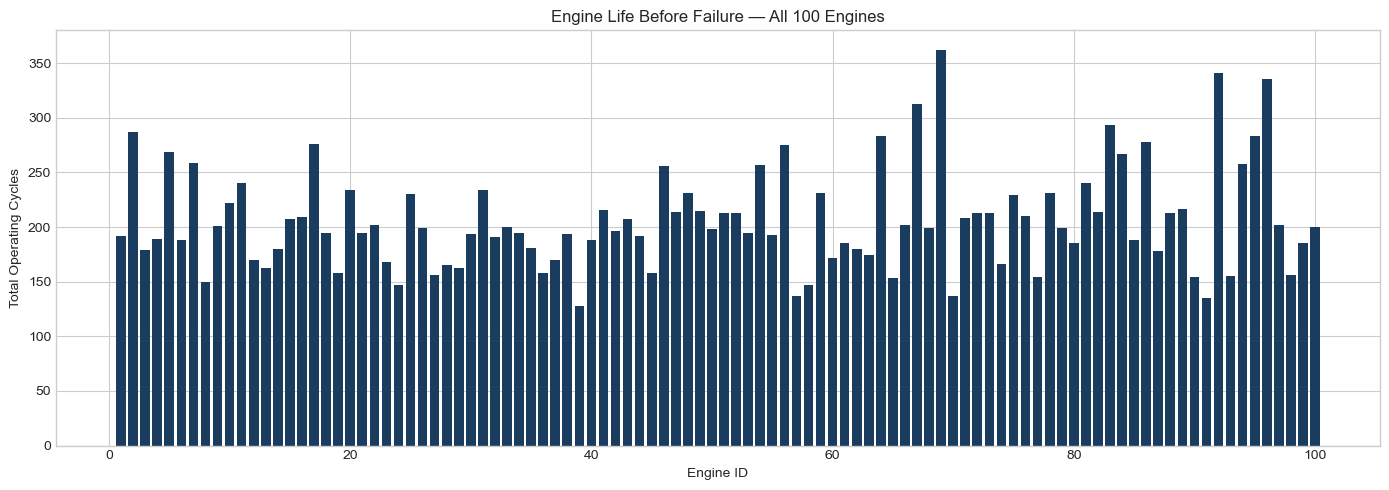

In [10]:
# Visualize how long each engine ran before failure
engine_life = train.groupby('engine_id')['cycle'].max()

plt.figure(figsize=(14, 5))
plt.bar(engine_life.index, engine_life.values, color='#1a3c5e')
plt.title('Engine Life Before Failure — All 100 Engines')
plt.xlabel('Engine ID')
plt.ylabel('Total Operating Cycles')
plt.tight_layout()
plt.show()


**Observation:** Operational life varies considerably across engines (roughly 130–360 cycles), confirming that RUL prediction is a genuine regression challenge rather than a fixed countdown.

## 9. Exploratory Data Analysis (EDA)

Key questions this section answers:
- How is RUL distributed across the dataset?
- Which sensors show meaningful variation, and which are essentially flat?
- Which sensors correlate most strongly with RUL?


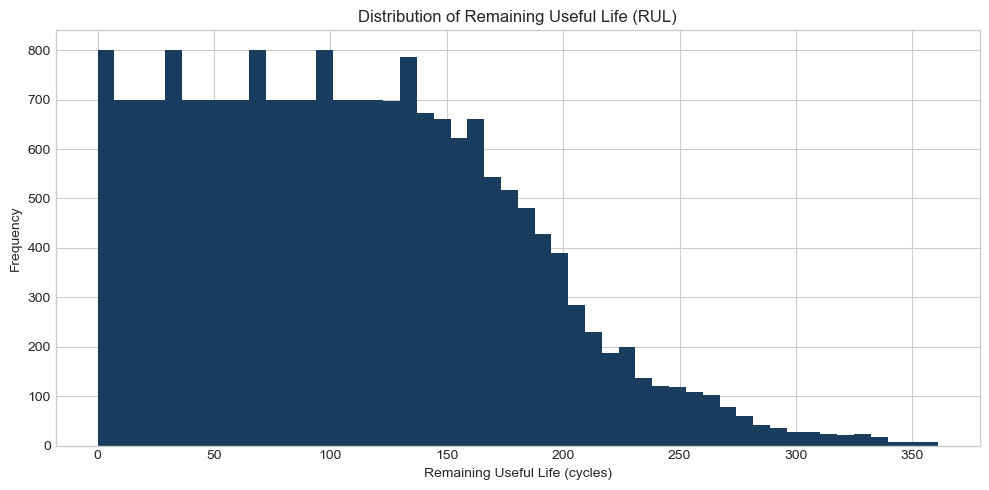

In [11]:
# Distribution of the target variable (RUL)
plt.figure(figsize=(10, 5))
plt.hist(train['RUL'], bins=50, color='#1a3c5e')
plt.title('Distribution of Remaining Useful Life (RUL)')
plt.xlabel('Remaining Useful Life (cycles)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [12]:
# Standard deviation of each sensor — identifies flat vs. informative sensors
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]
sensor_std = train[sensor_columns].std().sort_values()
sensor_std


sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_16    1.556432e-14
sensor_10    4.660829e-13
sensor_5     3.394700e-12
sensor_1     6.537152e-11
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

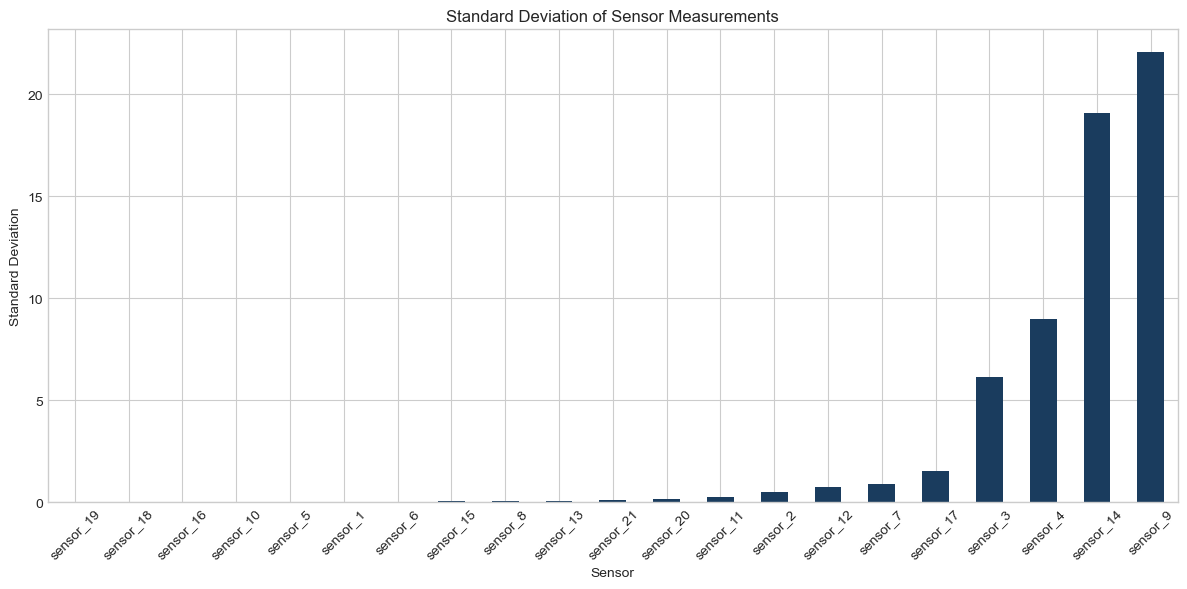

In [13]:
plt.figure(figsize=(12, 6))
sensor_std.plot(kind='bar', color='#1a3c5e')
plt.title('Standard Deviation of Sensor Measurements')
plt.xlabel('Sensor')
plt.ylabel('Standard Deviation')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** Sensors `sensor_1`, `sensor_5`, `sensor_6`, `sensor_10`, `sensor_16`, `sensor_18`, and `sensor_19` show near-zero standard deviation — these carry little to no useful signal and are dropped in the Feature Selection step below.

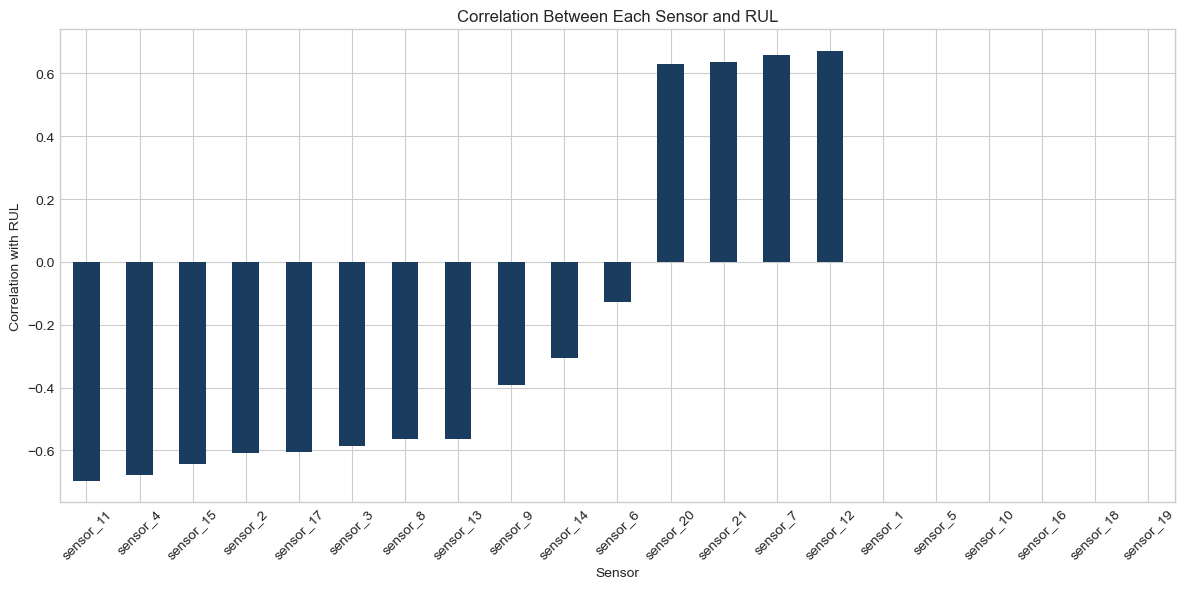

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64

In [14]:
# Correlation of each sensor with RUL
sensor_rul_corr = train[sensor_columns + ['RUL']].corr()['RUL'].drop('RUL').sort_values()

plt.figure(figsize=(12, 6))
sensor_rul_corr.plot(kind='bar', color='#1a3c5e')
plt.title('Correlation Between Each Sensor and RUL')
plt.xlabel('Sensor')
plt.ylabel('Correlation with RUL')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sensor_rul_corr


**Observation:** Sensors such as `sensor_11`, `sensor_4`, `sensor_12`, and `sensor_7` show the strongest correlation (positive or negative) with RUL — these are strong candidate predictors of engine degradation.

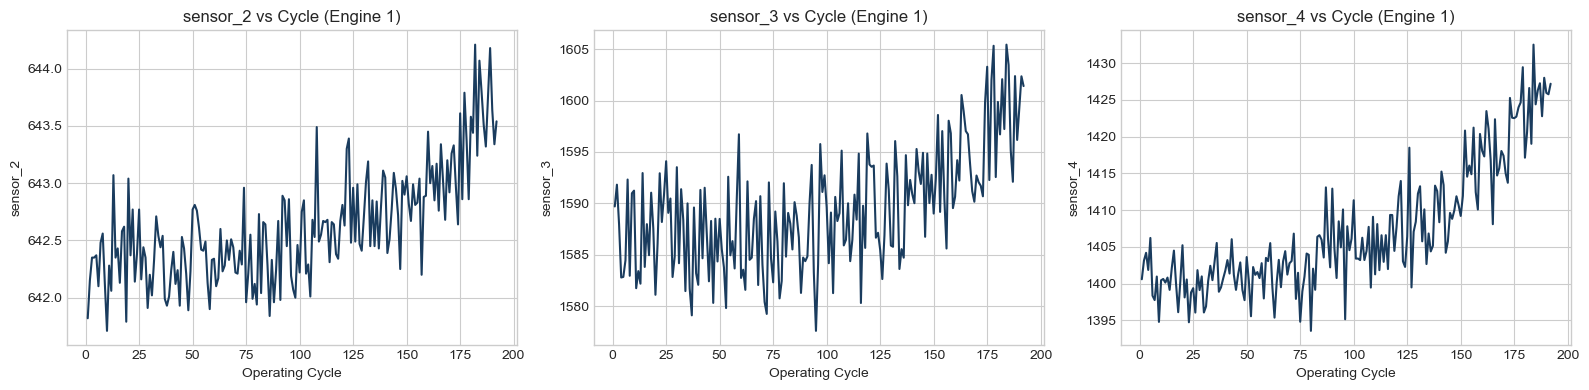

In [15]:
# Degradation trend example — Engine 1, three representative sensors
engine_1 = train[train['engine_id'] == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, sensor in zip(axes, ['sensor_2', 'sensor_3', 'sensor_4']):
    ax.plot(engine_1['cycle'], engine_1[sensor], color='#1a3c5e')
    ax.set_title(f'{sensor} vs Cycle (Engine 1)')
    ax.set_xlabel('Operating Cycle')
    ax.set_ylabel(sensor)
plt.tight_layout()
plt.show()


**Observation:** Sensor values drift steadily as the engine approaches failure — this degradation trend is exactly the pattern the model needs to learn to predict RUL.

## 10. Sensor Analysis & Feature Selection

Based on the standard deviation analysis above, sensors with **near-zero variance** are excluded — they carry no useful signal and would only add noise. Sensors are **not** dropped purely for having low linear correlation with RUL, since tree-based models can capture non-linear relationships that a correlation coefficient won't show.


In [16]:
# Sensors identified as near-zero variance (flat across all engines/cycles)
low_variance_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

selected_sensors = [s for s in sensor_columns if s not in low_variance_sensors]

print(f"Sensors retained: {len(selected_sensors)} of {len(sensor_columns)}")
selected_sensors


Sensors retained: 14 of 21


['sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_17',
 'sensor_20',
 'sensor_21']

In [17]:
# Final feature list and target variable
features = ['cycle', 'op_setting1', 'op_setting2', 'op_setting3'] + selected_sensors
target = 'RUL'

X = train[features]
y = train[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)


Features shape: (20631, 18)
Target shape: (20631,)


**Note:** `engine_id` is intentionally excluded from the feature list — it is an identifier, not a physical characteristic of engine health, and including it would let the model "memorize" specific engines rather than learn general degradation patterns.

## 11. Data Preparation

**Train/test split is done by `engine_id`, not by random rows.** This is critical: cycles from the same engine are highly correlated with each other (they're a time series), so a random row split would leak information between train and test sets and produce an unrealistically good — and misleading — score.


In [18]:
# Split by engine ID (80% engines for training, 20% for testing)
engine_ids = train['engine_id'].unique()
train_ids, test_ids = train_test_split(engine_ids, test_size=0.2, random_state=42)

X_train = train[train['engine_id'].isin(train_ids)][features]
y_train = train[train['engine_id'].isin(train_ids)][target]
X_test  = train[train['engine_id'].isin(test_ids)][features]
y_test  = train[train['engine_id'].isin(test_ids)][target]

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (16561, 18)
Test set: (4070, 18)


In [19]:
# Feature scaling — required for Linear Regression, harmless for tree models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 12. Model Building

Two models are trained and compared: a simple baseline, and a stronger ensemble model. Comparing them shows *why* the more complex model is justified, rather than just picking one.


### 12.1 Baseline Model — Linear Regression

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print(f"Linear Regression  ->  RMSE: {rmse_lr:.2f}   MAE: {mae_lr:.2f}   R2: {r2_lr:.3f}")


Linear Regression  ->  RMSE: 31.68   MAE: 25.17   R2: 0.767


### 12.2 Random Forest Regressor

In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print(f"Random Forest       ->  RMSE: {rmse_rf:.2f}   MAE: {mae_rf:.2f}   R2: {r2_rf:.3f}")


Random Forest       ->  RMSE: 30.81   MAE: 23.51   R2: 0.780


## 13. Model Comparison

In [22]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE':  [mae_lr, mae_rf],
    'R2':   [r2_lr, r2_rf]
}).sort_values('RMSE').reset_index(drop=True)

results


,Model,RMSE,MAE,R2
0,Random Forest,30.814917,23.510392,0.779693
1,Linear Regression,31.675902,25.173670,0.767211


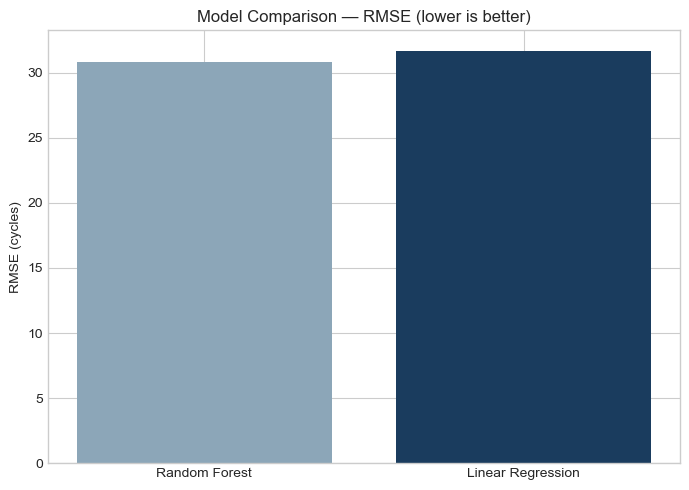

In [23]:
# Visual comparison of RMSE across models
plt.figure(figsize=(7, 5))
plt.bar(results['Model'], results['RMSE'], color=['#8ca6b8', '#1a3c5e'])
plt.title('Model Comparison — RMSE (lower is better)')
plt.ylabel('RMSE (cycles)')
plt.tight_layout()
plt.show()


**Observation:** Random Forest achieved the lower RMSE (30.81 vs. 31.68 cycles) and higher R² (0.780 vs. 0.767) compared to the Linear Regression baseline — roughly a 3% reduction in prediction error. The improvement is modest rather than dramatic, which suggests most of the signal in this dataset is fairly linear, though Random Forest still captures some additional non-linear degradation patterns Linear Regression misses.

## 14. Predicted vs Actual RUL — Best Model

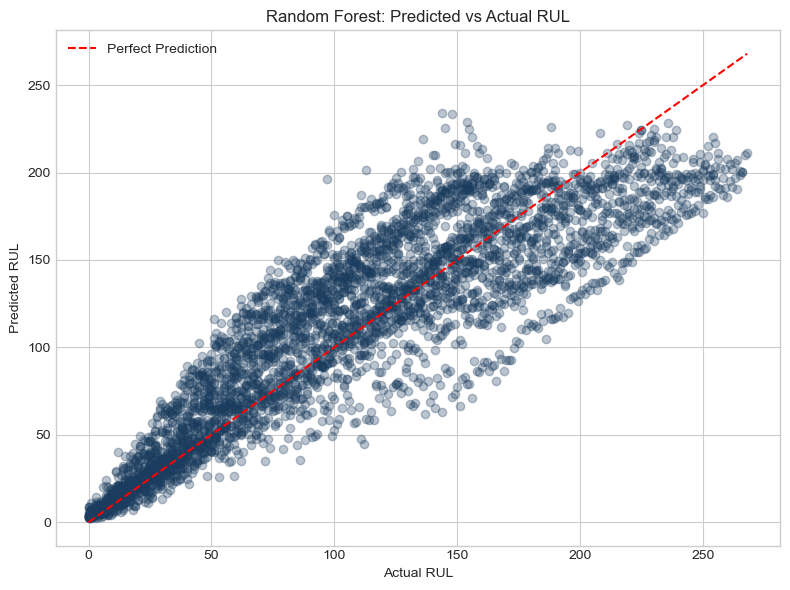

In [24]:
# Using Random Forest predictions (update if Linear Regression scored better)
best_pred = y_pred_rf
best_name = "Random Forest"

plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.3, color='#1a3c5e')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title(f'{best_name}: Predicted vs Actual RUL')
plt.legend()
plt.tight_layout()
plt.show()


**Observation:** Points closer to the red diagonal line indicate more accurate predictions. Typically, prediction error is smaller when RUL is low (engine close to failure) and larger when RUL is high — note whether that pattern holds here, since it directly affects how early a maintenance-planning alert would be reliable.

## 15. Feature Importance

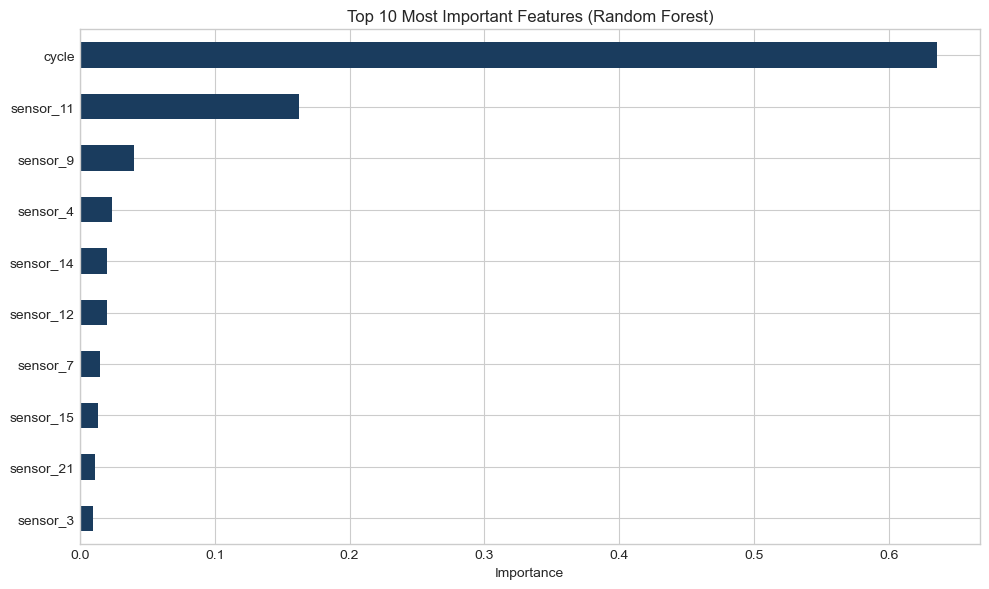

cycle        0.635539
sensor_11    0.162166
sensor_9     0.040568
sensor_4     0.023559
sensor_14    0.020519
sensor_12    0.020069
sensor_7     0.014651
sensor_15    0.013673
sensor_21    0.011523
sensor_3     0.009944
dtype: float64

In [25]:
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='#1a3c5e')
plt.title('Top 10 Most Important Features (Random Forest)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances.head(10)


**Observation:** The single most influential feature is `cycle` itself (63.5% importance) — unsurprising, since RUL is fundamentally a function of how long an engine has been running. Among the sensor readings, `sensor_11` is by far the strongest predictor (16.2%), followed by `sensor_9`, `sensor_4`, and `sensor_14` at single-digit importance each. `sensor_11` is worth naming specifically in an interview as the standout sensor-based predictor of engine degradation.

## 16. Business Impact & Conclusion

**Problem solved:** This project builds a model that predicts how many operating cycles remain before an engine fails, using only sensor readings collected during normal operation.

**Why this matters in industry:** In a manufacturing or industrial setting, the same approach applied to motors, rolling mills, or rotating equipment could:
- Shift maintenance from a **fixed calendar schedule** to a **condition-based** one — servicing equipment only when data shows it's actually needed
- Reduce **unplanned downtime**, which is typically far more costly than planned maintenance
- Extend equipment life by avoiding both premature replacement and run-to-failure damage

**Model performance summary:**
- Best model: Random Forest
- RMSE: 30.81 cycles (R² = 0.780)
- This means predictions are typically off by about 31 operating cycles. For engines with a typical lifespan of 130–360 cycles, this is a meaningful early-warning margin — enough advance notice to schedule maintenance before failure rather than reacting to it.

**Personal relevance:** This project connects directly to 5+ years of hands-on experience with PLC, SCADA, and Level 2 automation systems — the same type of sensor data streams used here, applied in a real steel manufacturing environment. This is the natural bridge from industrial automation into applied data science and predictive maintenance.

**Possible future extensions:**
- Try XGBoost or hyperparameter tuning once comfortable with the current pipeline, to see if it improves on Random Forest
- LSTM/sequence models to capture temporal patterns more explicitly
- Deploy the trained model behind a simple Streamlit app for interactive RUL prediction


---
### 📌 About This Project
This notebook is part of a self-directed data analytics portfolio. Feedback and suggestions are welcome — feel free to connect on [LinkedIn](https://www.linkedin.com/in/pramila-r) or check out more projects on [GitHub](https://github.com/Pramila6578).
